# Numerical uncertainty and readable centreline results
**Run this first to review your existing completed run. No reconstruction or cache rebuild is required.** It reads saved field/centre summaries and computes CE-minus-AE centreline contrasts from saved per-eddy centrelines.

Numerical intervals and zoomed panels expose small offsets hidden by extreme member trajectories. Sections stop at the actual shallowest/deepest reconstructed levels. Means and shaded intervals do not imply continuous vertical information between the fitted depths.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import seacofs_tilt_tools as tilt
import population_tools as pop
pd.set_option('display.max_columns', 60)


In [2]:
OUTPUT_ROOT = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites')
RUN_PATH = None  # e.g. OUTPUT_ROOT/'39f937013b2719bf' for the original run
run = Path(RUN_PATH) if RUN_PATH else Path((OUTPUT_ROOT/'latest_run.txt').read_text().strip())
results, depths, coordinate, config = pop.load_saved_results(run)
manifest = pd.read_csv(run/'members/members.csv')
report = run/'report_v2'
report.mkdir(exist_ok=True)
print('Source run:', run)
print('Exact depths (m):', depths)
print('Units:', config['units'])
# Original run provenance stays unchanged. Record the reporting implementation separately.
import hashlib
(report/'report_provenance.json').write_text(json.dumps(dict(
    source_run=str(run), source_config=config,
    reporting_code_sha256=hashlib.sha256(Path(pop.__file__).read_bytes()).hexdigest()), indent=2))


Source run: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites/5c87d801bc8b95e7
Exact depths (m): [  0.           5.8796272   10.72578341  16.38309659  22.92558077
  30.44411824  39.05271243  48.89763802  60.17063863  73.12784158
  88.11683809 105.61553821 126.28812669 151.06595427 181.26479327
 218.75485612 266.2063977  327.44085148 407.92219179 515.41648935]
Units: Rc


1254

,group,depth_m,component,units,eddies,days,mean,ci_low,ci_high,excludes_zero,tilt_mean,tilt_ci_low,tilt_ci_high
0,AE_Planetary,0.000000,east,Rc,382,3926,0.000000,0.000000,0.000000,False,-0.000000,-0.000000,-0.000000
1,AE_Planetary,0.000000,north,Rc,382,3926,0.000000,0.000000,0.000000,False,-0.000000,-0.000000,-0.000000
2,AE_Planetary,5.879627,east,Rc,382,3926,0.004687,0.001147,0.008349,True,-0.004687,-0.008349,-0.001147
3,AE_Planetary,5.879627,north,Rc,382,3926,-0.004478,-0.008828,0.000459,False,0.004478,-0.000459,0.008828
4,AE_Planetary,10.725783,east,Rc,382,3926,0.006531,0.001749,0.011229,True,-0.006531,-0.011229,-0.001749
5,AE_Planetary,10.725783,north,Rc,382,3926,-0.008891,-0.014283,-0.002383,True,0.008891,0.002383,0.014283
6,AE_Planetary,16.383097,east,Rc,382,3926,0.009337,0.004106,0.014475,True,-0.009337,-0.014475,-0.004106
7,AE_Planetary,16.383097,north,Rc,382,3926,-0.011822,-0.018062,-0.004964,True,0.011822,0.004964,0.018062
8,AE_Planetary,22.925581,east,Rc,382,3926,0.012419,0.006650,0.018184,True,-0.012419,-0.018184,-0.006650
9,AE_Planetary,22.925581,north,Rc,382,3926,-0.014379,-0.021561,-0.006820,True,0.014379,0.006820,0.021561


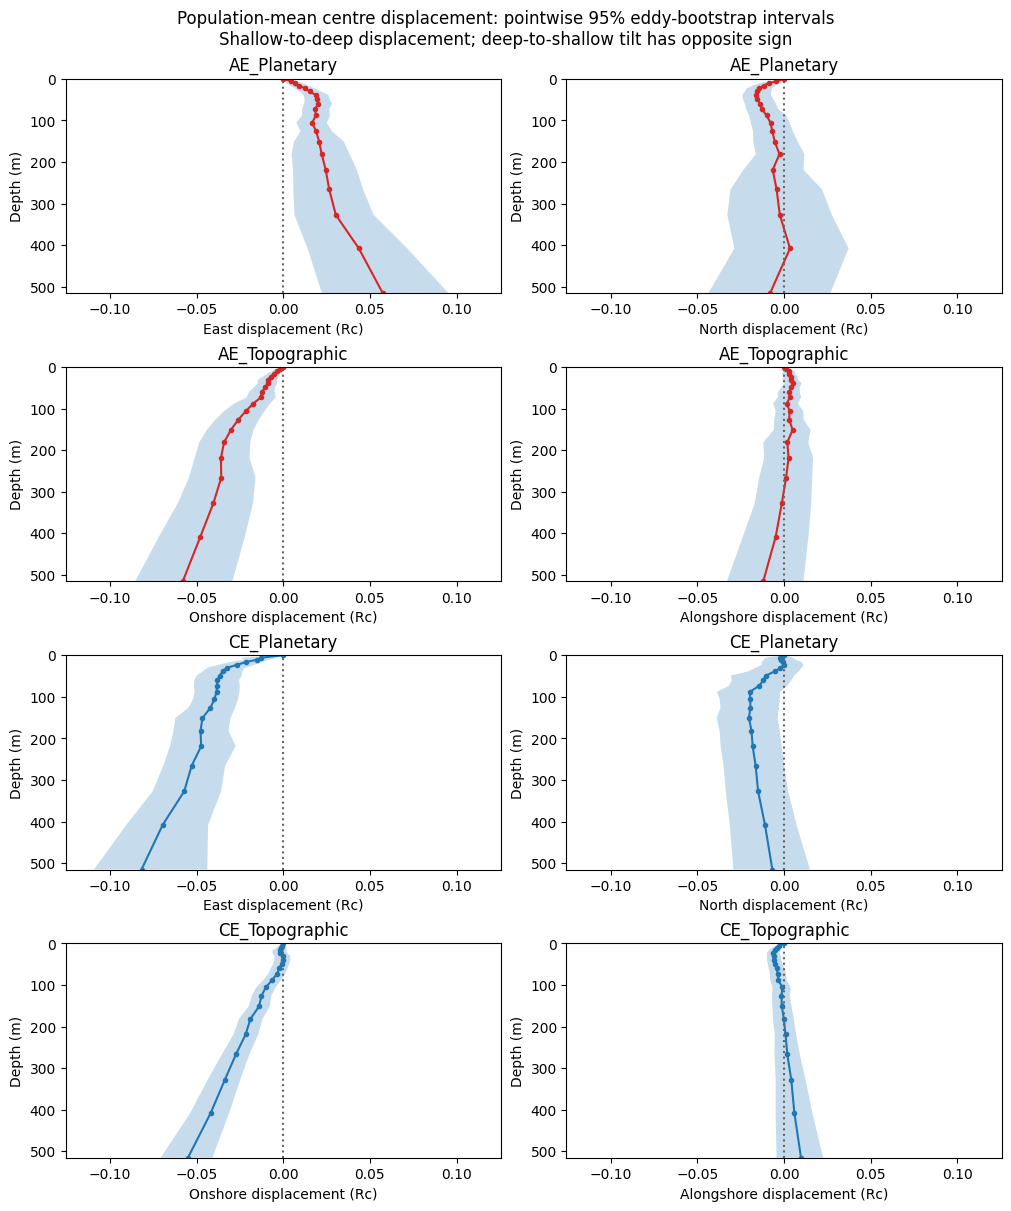

In [3]:
intervals = pop.centre_interval_table(results, depths, config['units'])
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(intervals.round(6))
intervals.to_csv(report/'centre_intervals.csv', index=False)
fig = pop.plot_zoomed_centres(results, depths, config['units'])
fig.savefig(report/'zoomed_centrelines.png', dpi=180)
plt.show()


## Raw polarity contrasts within each regime
The contrast is **CE minus AE shallow-to-deep centre displacement**; its negative is the contrast in deep-to-shallow tilt. Whole-eddy draws preserve covariance for eddies appearing in multiple groups. Intervals describe raw population differences, not a causal polarity effect or a spatially matched comparison. `excludes_zero` is a pointwise diagnostic, not a multiple-testing-adjusted finding.

In [4]:
contrasts = pop.centre_contrasts(manifest, run/'members', depths,
                                n_boot=config['n_boot'], seed=config['seed'],
                                min_members=config['min_eddies'])
contrasts['units'] = config['units']
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(contrasts.round(6))
contrasts.to_csv(report/'centre_CE_minus_AE.csv', index=False)


,regime,depth_m,component,contrast,mean,ci_low,ci_high,AE_eddies,CE_eddies,excludes_zero,units
0,Planetary,0.000000,east,CE minus AE centre displacement,0.000000,0.000000,0.000000,382,317,False,Rc
1,Planetary,0.000000,north,CE minus AE centre displacement,0.000000,0.000000,0.000000,382,317,False,Rc
2,Planetary,5.879627,east,CE minus AE centre displacement,-0.017563,-0.029073,-0.007228,382,317,True,Rc
3,Planetary,5.879627,north,CE minus AE centre displacement,0.002302,-0.007536,0.010962,382,317,False,Rc
4,Planetary,10.725783,east,CE minus AE centre displacement,-0.021575,-0.030423,-0.013082,382,317,True,Rc
5,Planetary,10.725783,north,CE minus AE centre displacement,0.007397,-0.003881,0.016618,382,317,False,Rc
6,Planetary,16.383097,east,CE minus AE centre displacement,-0.030961,-0.042132,-0.020894,382,317,True,Rc
7,Planetary,16.383097,north,CE minus AE centre displacement,0.011188,-0.001164,0.022561,382,317,False,Rc
8,Planetary,22.925581,east,CE minus AE centre displacement,-0.039002,-0.052086,-0.028201,382,317,True,Rc
9,Planetary,22.925581,north,CE minus AE centre displacement,0.014509,0.001005,0.026442,382,317,True,Rc


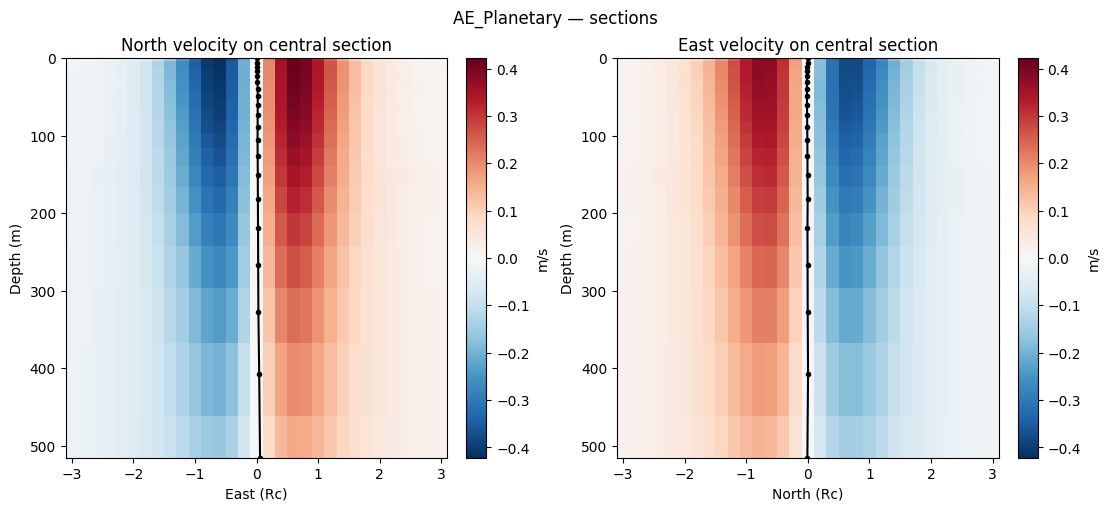

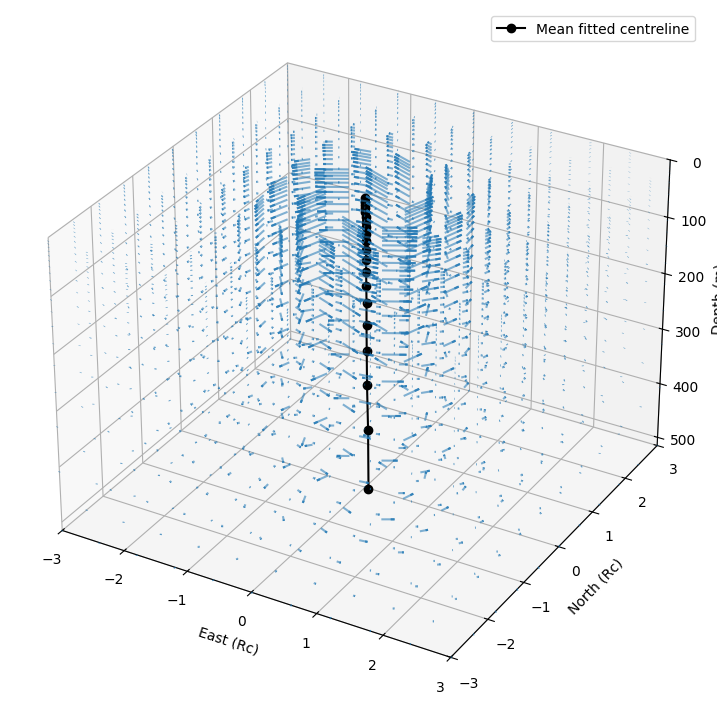

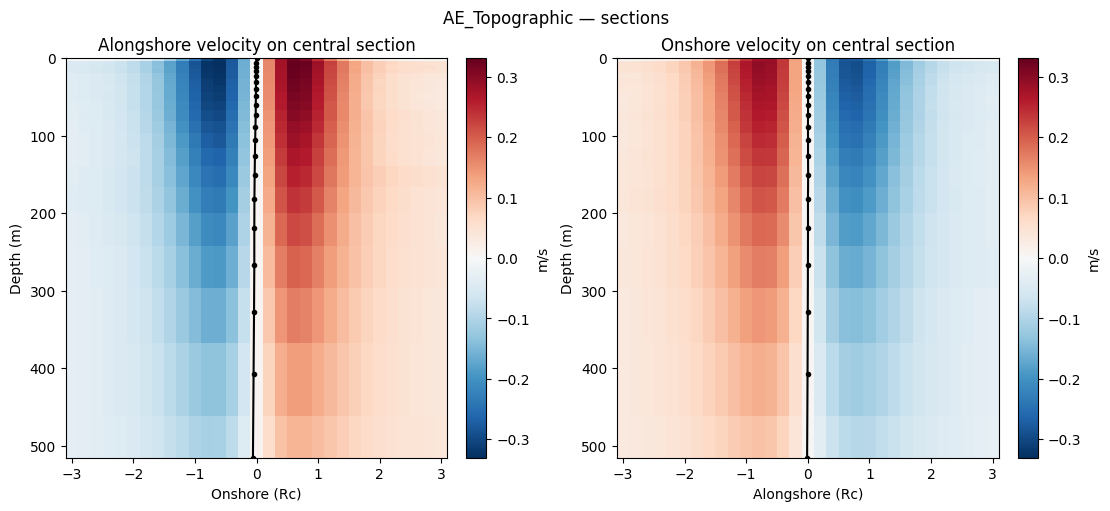

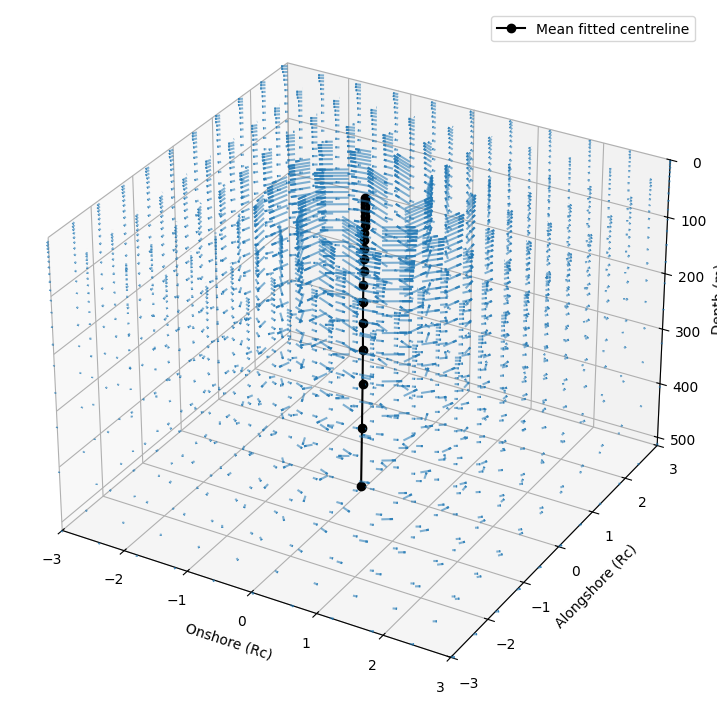

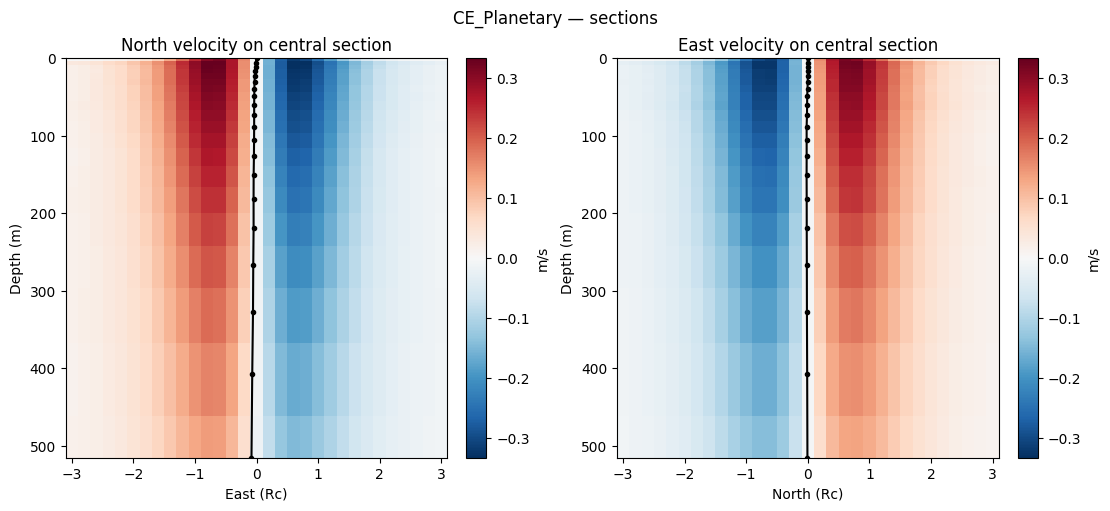

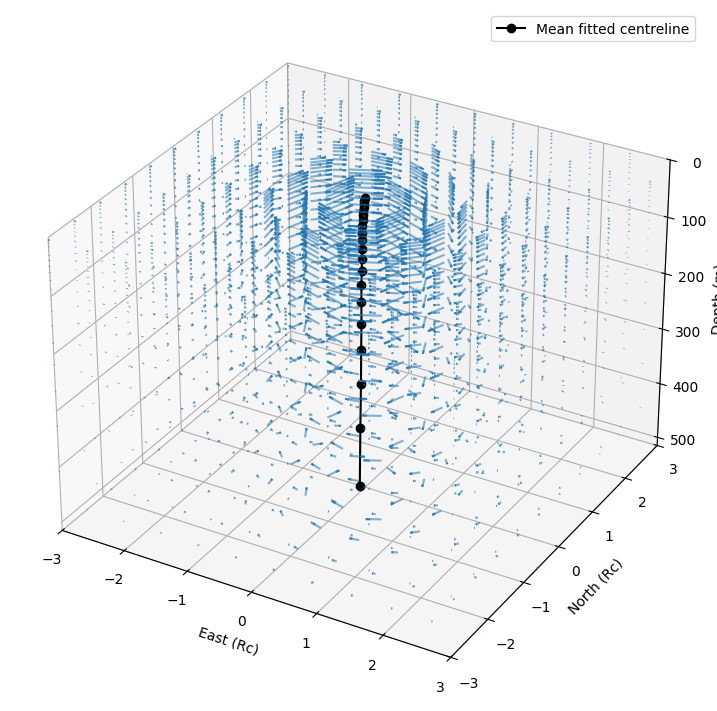

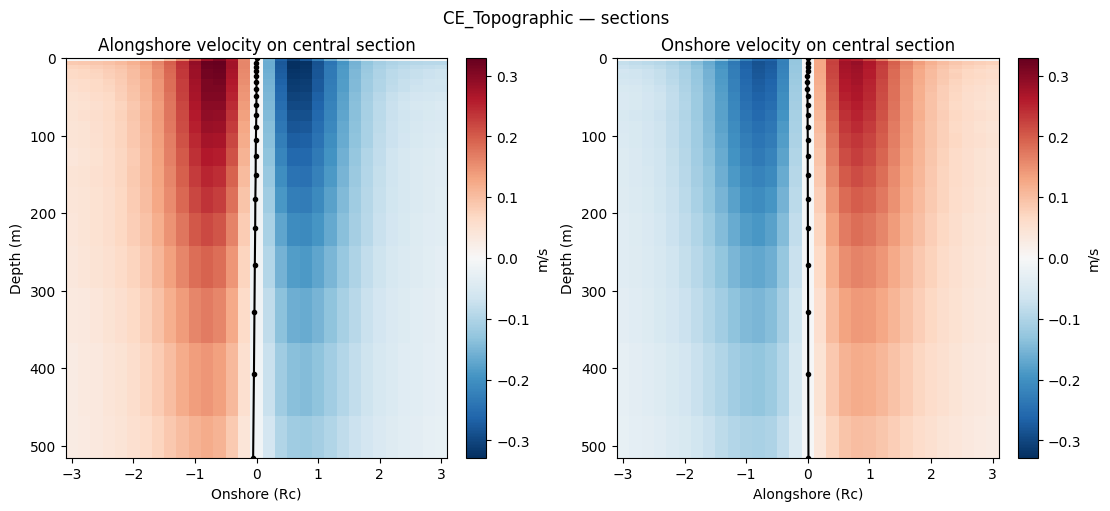

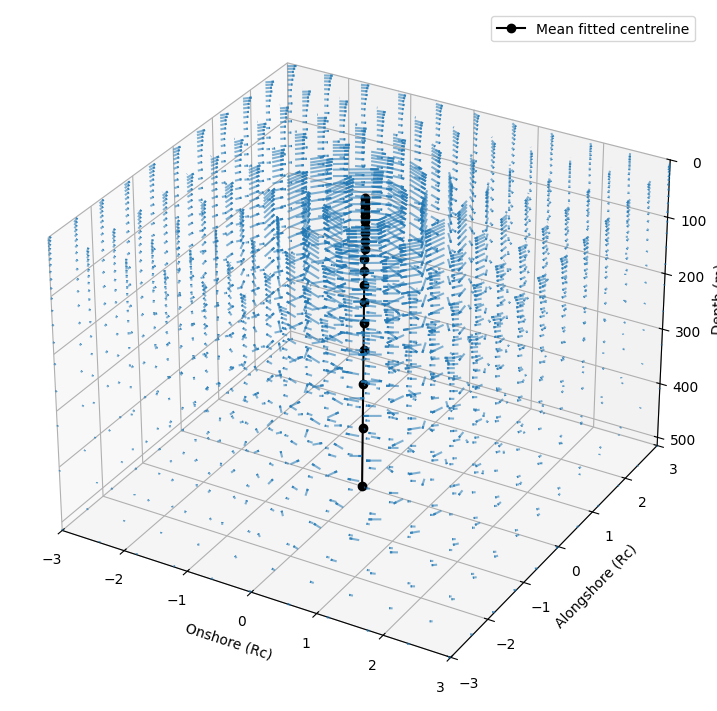

Updated report: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites/5c87d801bc8b95e7/report_v2


In [5]:
for group, result in results.items():
    figures = pop.plot_sections_3d(result, depths, coordinate, config['units'])
    for suffix, fig in figures:
        fig.suptitle(group+' — '+suffix)
        fig.savefig(report/f'{group}_{suffix}.png', dpi=180)
        plt.show()
print('Updated report:', report)
